# Инструменты для анализа и предобработки данных

Цель данной лабораторной работы - вспомнить инструментарий pandas, SQL и matplotlib для проведения анализа и предобработки данных.

С точки зрения машинного обучения в данной работе будет рассмотрен алгоритм kNN, алгоритм кластеризации kMeans, а также некоторые методы снижения размерности.

Датасет, с которым вам предстоит работать, содержит информацию о покупателях в одном из магазинов. Данные разделены на несколько файлов.
<br><br>
**people**

`id`: уникальный идентификатор клиента

`year_birth`: год рождения клиента

`education`: уровень образования клиента

`marital_status`: семейное положение клиента

`income`: годовой доход семьи клиента

`kidhome`: количество детей в доме клиента

`teenhome`: количество подростков в доме клиента

`dt_customer`: дата регистрации клиента в компании

`recency`: количество дней с момента последней покупки клиента

`complain`: 1, если клиент жаловался в последние 2 года, 0 в противном случае
<br><br>
**products**

`id`: уникальный идентификатор клиента

`mntwines`: сумма, потраченная на вино за последние 2 года

`mntfruits`: сумма, потраченная на фрукты за последние 2 года

`mntmeatproducts`: сумма, потраченная на мясные продукты за последние 2 года

`mntfishproducts`: сумма, потраченная на рыбу за последние 2 года

`mntsweetproducts`: сумма, потраченная на сладости за последние 2 года

`mntgoldprods`: сумма, потраченная на золото за последние 2 года
<br><br>
**purchases**

`id`: уникальный идентификатор клиента

`numwebpurchases`: количество покупок через веб-сайт компании

`numcatalogpurchases`: количество покупок с использованием каталога

`numstorepurchases`: количество покупок непосредственно в магазинах

`numwebvisitsmonth`: количество посещений веб-сайта компании в последний месяц

`numdealspurchases`: количество покупок скидочных товаров

In [1]:
# Подробно:
# 1) Скачиваем архив customers.zip с Google Drive через gdown.
# 2) Распаковываем архив, чтобы получить CSV-файлы с данными.

# выполняем команду оболочки
!gdown 1LUjAJR6hNs5IAnQscisvM2hUemvYRLWy
# выполняем команду оболочки
!unzip customers.zip

Downloading...
From: https://drive.google.com/uc?id=1LUjAJR6hNs5IAnQscisvM2hUemvYRLWy
To: /content/customers.zip
100% 66.6k/66.6k [00:00<00:00, 79.4MB/s]
Archive:  customers.zip
  inflating: products.csv            
  inflating: people.csv              
  inflating: purchases.csv           


## pandas, sql

Прочитайте данные. Сколько строк и столбцов содержат таблицы? Есть ли в данных пропуски?

In [2]:
# Подробно:
# 1) Подключаем pandas для чтения и анализа таблиц.
# 2) Загружаем таблицы products/people/purchases с нужными разделителями.
# 3) Выводим размеры таблиц и число пропусков по столбцам.

# импортируем библиотеки
import pandas as pd

# задаем или обновляем products
products = pd.read_csv('products.csv', sep='\t')
# задаем или обновляем people
people = pd.read_csv('people.csv', sep=';')
# задаем или обновляем purchases
purchases = pd.read_csv('purchases.csv')

# выводим результат
print(f'Таблица products: \n {products.shape} \n количество пропусков в таблице products: {products.isnull().sum()} \n')
# выводим результат
print(f'Таблица people: \n {people.shape} \n количество пропусков в таблице people: {people.isnull().sum()} \n')
# выводим результат
print(f'Таблица purchases: \n {purchases.shape} \n количество пропусков в таблице purchases: {purchases.isnull().sum()} \n')

Таблица products: 
 (2240, 7) 
 количество пропусков в таблице products: id                  0
mntwines            0
mntfruits           0
mntmeatproducts     0
mntfishproducts     0
mntsweetproducts    0
mntgoldprods        0
dtype: int64 

Таблица people: 
 (2240, 10) 
 количество пропусков в таблице people: id                 0
year_birth         0
education          0
marital_status     0
income            24
kidhome            0
teenhome           0
dt_customer        0
recency            0
complain           0
dtype: int64 

Таблица purchases: 
 (2240, 6) 
 количество пропусков в таблице purchases: id                     0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
dtype: int64 



Каждое из следующих заданий необходимо выполнить двумя способами - с помощью pandas и с помощью SQL. Не используйте объединение таблиц через join/merge/concat.

In [3]:
# Подробно:
# 1) Создаем in-memory базу SQLite для выполнения SQL-запросов.
# 2) Переносим pandas-таблицы в SQLite через to_sql.
# 3) Выполняем пробный SELECT и читаем результат обратно в pandas.

# импортируем библиотеки
import sqlite3

# задаем или обновляем conn
conn = sqlite3.connect(':memory:')  # создание временной базы данных

# задаем или обновляем people.to_sql('people', conn, index
people.to_sql('people', conn, index=False)
# задаем или обновляем products.to_sql('products', conn, index
products.to_sql('products', conn, index=False)
# задаем или обновляем purchases.to_sql('purchases', conn, index
purchases.to_sql('purchases', conn, index=False)

# задаем или обновляем query
query = "SELECT * FROM people LIMIT 5;"
# задаем или обновляем result
result = pd.read_sql_query(query, conn)
# выполняем шаг вычисления
result

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0


### 1

Найдите абсолютную разницу между минимальным доходом клиентов с детьми и максимальным доходом клиентов без детей. Учитывайте только столбец `kidhome`.

In [4]:
# Подробно:
# 1) Берем минимальный доход у семей с детьми.
# 2) Берем максимальный доход у семей без детей.
# 3) Считаем модуль разницы и печатаем его.

# задаем или обновляем with_kids
with_kids = people.loc[people['kidhome'] > 0, 'income'].min()
# выполняем шаг вычисления
no_kids = people.loc[people['kidhome'] == 0, 'income'].max()

# выводим результат
print(abs(no_kids - with_kids))

158356.0


In [5]:
# Подробно:
# 1) Пишем SQL-запрос для той же разницы между группами.
# 2) Читаем результат через pandas и выводим его.

# выполняем шаг вычисления
query = "Select abs(min(case when kidhome > 0 then income end) - max(case when kidhome == 0 then income end)) as diff from people"
# задаем или обновляем result
result = pd.read_sql_query(query, conn)
# выполняем шаг вычисления
result


,diff
0,158356.0


### 2
Посчитайте процентное соотношение клиентов, имеющих PhD или другой уровень образования, среди клиентов, покупающих и не покупающих сладкое. Ответ представьте в виде:

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        th, td {
            text-align: center;
            padding: 10px;
        }
        th {
            font-weight: bold;
        }
    </style>
</head>
<body>

<table border="1">
  <tr>
    <th></th>
    <th>PhD</th>
    <th>Other</th>
  </tr>
  <tr>
    <th>Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
  <tr>
    <th>No Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
</table>

</body>
</html>

Сумма по строке должна давать единицу.

In [7]:
# Подробно:
# 1) Формируем id покупателей сладостей и тех, кто сладости не покупал.
# 2) В функции edu_shares считаем долю PhD и долю остальных.
# 3) Считаем доли для обеих групп и собираем в DataFrame.
# 4) Печатаем итоговую таблицу.

# задаем или обновляем sweets_ids
sweets_ids = set(products.loc[products['mntsweetproducts'] > 0, 'id'])
# выполняем шаг вычисления
nosweets_ids = set(products.loc[products['mntsweetproducts'] == 0, 'id'])

# определяем функцию edu_shares
def edu_shares(ids):
    # задаем или обновляем sub
    sub = people.loc[people['id'].isin(ids), ['education']].dropna()

    # выполняем шаг вычисления
    phd = (sub['education'] == 'PhD').sum()
    # задаем или обновляем total
    total = len(sub)

    # задаем или обновляем phd_share
    phd_share = phd / total
    # задаем или обновляем other_share
    other_share = 1 - phd_share

    # возвращаем результат
    return phd_share, other_share



# задаем или обновляем sweets_phd, sweets_other
sweets_phd, sweets_other = edu_shares(sweets_ids)
# задаем или обновляем nosweets_phd, nosweets_other
nosweets_phd, nosweets_other = edu_shares(nosweets_ids)

# задаем или обновляем result
result = pd.DataFrame(
    # выполняем шаг вычисления
    {
        # выполняем шаг вычисления
        "PhD":   [sweets_phd,   nosweets_phd],
        # выполняем шаг вычисления
        "Other": [sweets_other, nosweets_other],
    # выполняем шаг вычисления
    },
    # задаем или обновляем index
    index=["Sweets", "No Sweets"]
# выполняем шаг вычисления
)

# выводим результат
print(result)



                PhD     Other
Sweets     0.182867  0.817133
No Sweets  0.365155  0.634845


In [14]:
# Подробно:
# 1) SQL-версия подсчета долей PhD/Other по группам Sweets/No Sweets.
# 2) Группируем, считаем среднюю долю PhD, задаем порядок строк.
# 3) Переносим в pandas, выставляем индекс и печатаем.

# задаем или обновляем query
query = """
# выполняем шаг вычисления
select
  # выполняем шаг вычисления
  grp,
  # выполняем шаг вычисления
  phd_share as phd,
  # выполняем шаг вычисления
  (1.0 - phd_share) as other

# выполняем шаг вычисления
from
# выполняем шаг вычисления
(
# выполняем шаг вычисления
select
  # выполняем шаг вычисления
  case
    # выполняем шаг вычисления
    when id in (select id from products where mntsweetproducts > 0) then 'Sweets'
    # ветка иначе
    else 'No Sweets'
    # выполняем шаг вычисления
    end as grp,
    # задаем или обновляем avg(case when education
    avg(case when education = 'PhD' then 1.0 else 0.0 end) as phd_share
# импортируем объекты из модуля
from people
# выполняем шаг вычисления
where id in (select id from products)
# выполняем шаг вычисления
group by
  # выполняем шаг вычисления
  case
    # выполняем шаг вычисления
    when id in (select id from products where mntsweetproducts > 0) then 'Sweet'
    # ветка иначе
    else 'No Sweet'
    # выполняем шаг вычисления
    end
# выполняем шаг вычисления
)
# задаем или обновляем order by case when grp
order by case when grp = 'Sweets' then 1 else 2 end;
# выполняем шаг вычисления
"""



# задаем или обновляем result
result = pd.read_sql_query(query, conn)

# задаем или обновляем result
result = result.set_index("grp")[["phd", "other"]]

# выводим результат
print(result)

                phd     other
grp                          
Sweets     0.182867  0.817133
No Sweets  0.365155  0.634845


## EDA

Изучите графики, которые предлагает построить Google Colab. Какие из них несут смысл, а какие выглядят бесполезными? На основании изученных графиков сформулируйте любую гипотезу по данным и постройте график, который поможет подтвердить или опровергнуть вашу гипотезу. Ваш график должен отличаться от уже представленных!

**people**

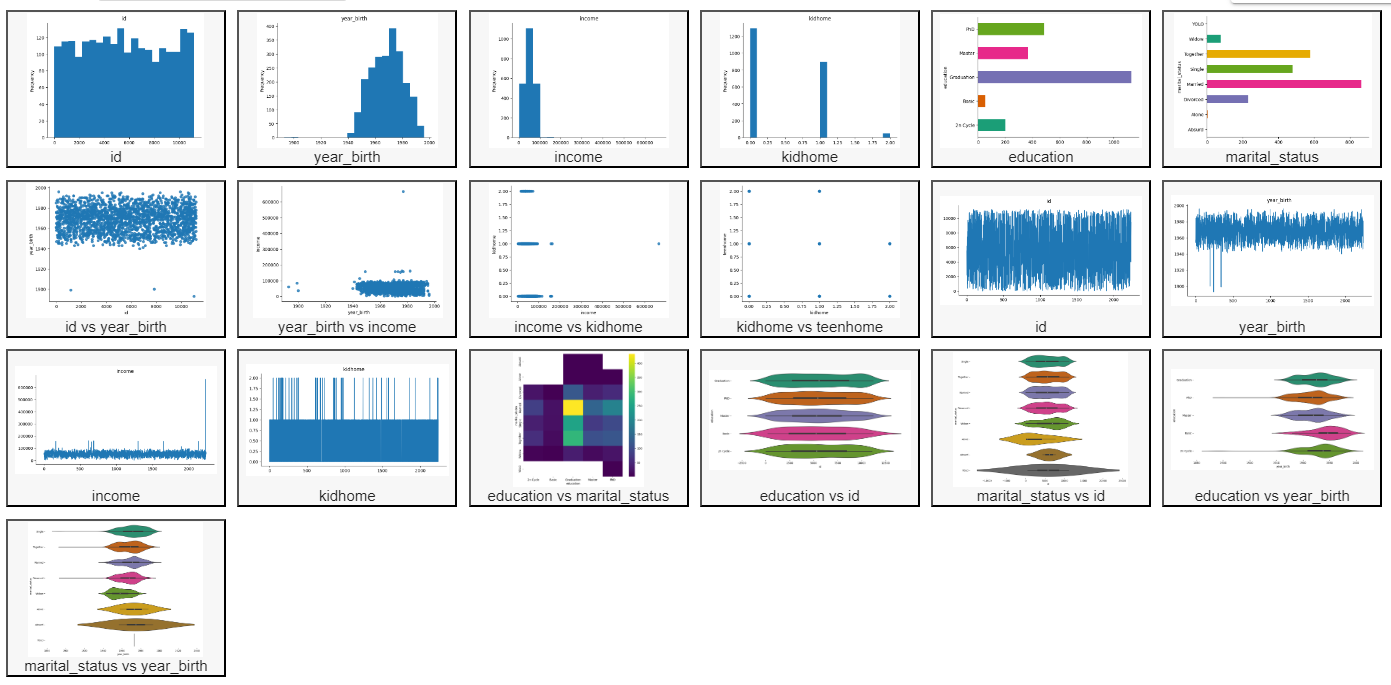

**products**

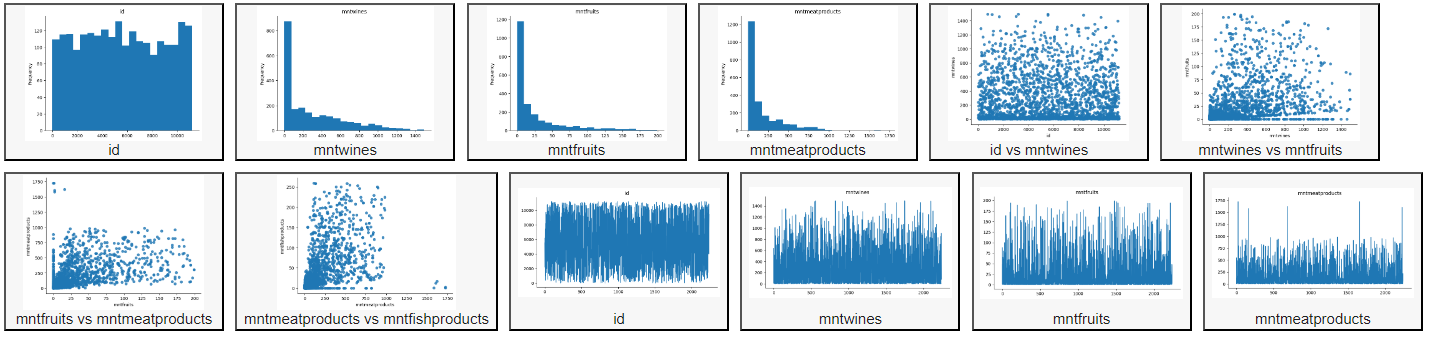

**purchases**

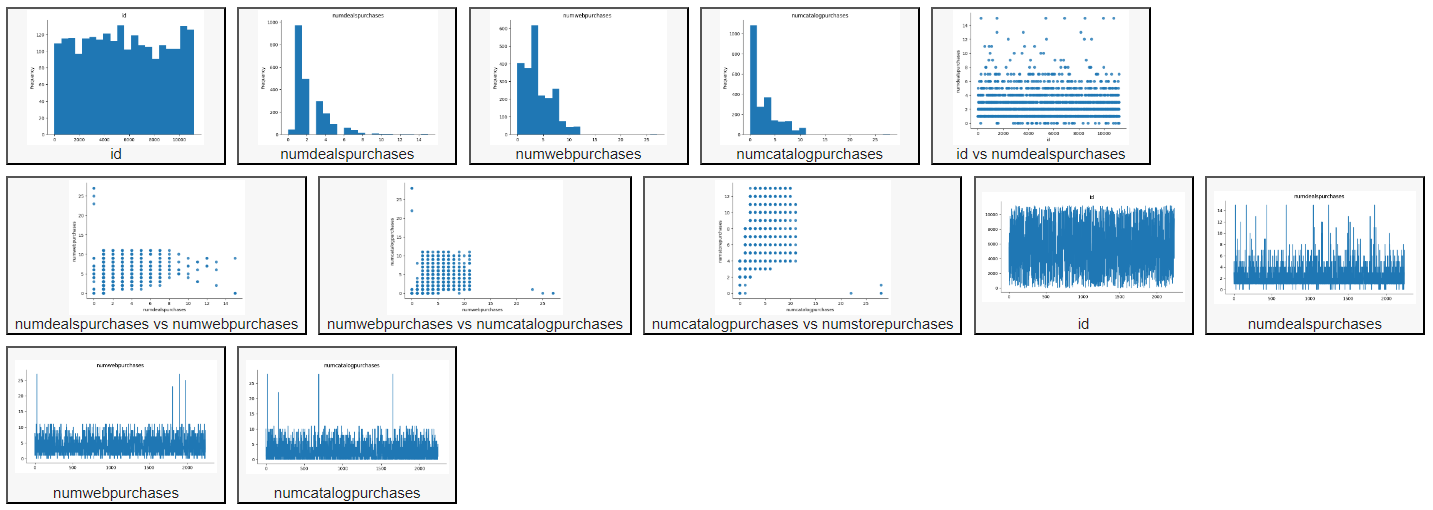

Гипотеза: Клиенты с более высоким доходом тратят больше на вино

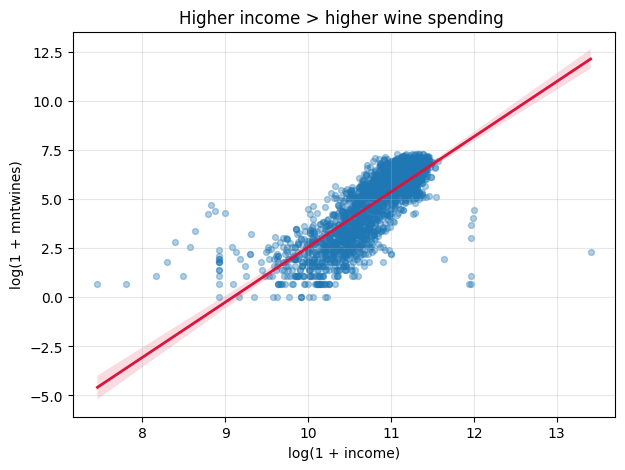

In [20]:
# Подробно:
# 1) Собираем таблицу с id, доходом и тратами на вино.
# 2) Удаляем пропуски и некорректные значения.
# 3) Применяем log1p для сглаживания распределений.
# 4) Строим регрессионный график дохода и трат на вино.

# импортируем библиотеки
import numpy as np
# импортируем библиотеки
import pandas as pd
# импортируем библиотеки
import seaborn as sns
# импортируем библиотеки
import matplotlib.pyplot as plt

# задаем или обновляем income_map
income_map = people.set_index('id')['income'].to_dict()

# задаем или обновляем df
df = products[['id', 'mntwines']].copy()
# задаем или обновляем df['income']
df['income'] = df['id'].map(income_map)


# задаем или обновляем df
df = df.dropna(subset=['income'])
# выполняем шаг вычисления
df = df[(df['income'] > 0) & (df['mntwines'] >= 0)]


# задаем или обновляем df['income_log']
df['income_log'] = np.log1p(df['income'])
# задаем или обновляем df['wines_log']
df['wines_log'] = np.log1p(df['mntwines'])

# строим или настраиваем график
plt.figure(figsize=(7,5))
# строим график с seaborn
sns.regplot(
    # задаем или обновляем data
    data=df,
    # задаем или обновляем x
    x='income_log',
    # задаем или обновляем y
    y='wines_log',
    # задаем или обновляем scatter_kws
    scatter_kws={'alpha': 0.35, 's': 18},
    # задаем или обновляем line_kws
    line_kws={'color': 'crimson', 'lw': 2},
    # задаем или обновляем ci
    ci=95
# выполняем шаг вычисления
)
# строим или настраиваем график
plt.xlabel('log(1 + income)')
# строим или настраиваем график
plt.ylabel('log(1 + mntwines)')
# строим или настраиваем график
plt.title('Higher income > higher wine spending ')
# строим или настраиваем график
plt.grid(alpha=0.3)
# строим или настраиваем график
plt.show()


## Предобработка данных

Соберём разрозненные таблицы в одну (и порадуемся, что их объём позволяет это сделать). Как мы помним, в данных были пропуски.

In [21]:
# Подробно:
# 1) Объединяем people, products и purchases по id.
# 2) Проверяем, сколько пропусков в объединенной таблице.

# задаем или обновляем df
df = pd.merge(pd.merge(people, products, on='id'), purchases, on='id')
# работаем с таблицей данных
df.isna().sum()

,0
id,0
year_birth,0
education,0
marital_status,0
income,24
kidhome,0
teenhome,0
dt_customer,0
recency,0
complain,0


Не все алгоритмы машинного обучения умеют работать с пропусками в данных. Есть несколько стратегий для борьбы с пропусками, самая частая - заполнение пропусков модой, медианой или средним. Если пропусков слишком много, то имеет смысл выбросить соответствующую строку или столбец целиком.

Есть и более продвинутые методы, например kNN (K Nearest Neighbours). Суть данного метода заключается в том, что на основании известных признаков для объекта находятся "соседи", располагающиеся как можно ближе к исходному объекту в пространстве. Затем по этим объектам вычисляется значение недостающего признака.

Возникает два вопроса:

1. Каким образом представить объекты в пространстве?
2. Как считать расстояние между ними?

Ответ на оба — зависит от задачи. Объект обычно проще всего представить как вектор признаков. Для подсчета расстояния используются, например:
- евклидово расстояние и его общий случай (расстояние минковского);
- косинусное расстояние;
- манхэттенское расстояние
- расстояние Чебышёва;
- какое угодно, придуманное вами.

Реализуем kNN для восстановления пропущенных значений `income`. Будем считать евклидово расстояние между векторами. Сначала превратим каждую строку в числовой вектор. Для этого выполним следующие шаги:

* удалим столбец `id`

* проведём one-hot кодирование столбцов `education` и `marital_status`

* проведём нормировку (min-max scaling) столбца `dt_customer`

* проведём нормализацию (z-scaling) полученных векторов, потому что евклидово расстояние чувствительно к размерности признаков

Подумайте, почему именно такие преобразования являются необходимыми.

In [40]:
# Подробно:
# 1) Убираем id, чтобы не мешать моделям.
# 2) One-hot кодируем education и marital_status.
# 3) Преобразуем дату в число дней от минимума и нормализуем.
# 4) Формируем матрицу признаков X и таргет y=income.
# 5) Заполняем числовые пропуски медианой и стандартизируем признаки.

# импортируем объекты из модуля
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# задаем или обновляем df_knn
df_knn = df.drop(columns=["id"]).copy()

# задаем или обновляем df_knn
df_knn = pd.get_dummies(df_knn, columns=["education", "marital_status"], drop_first=False)

# задаем или обновляем df_knn["dt_customer"]
df_knn["dt_customer"] = pd.to_datetime(df_knn["dt_customer"], dayfirst=True, errors="coerce")

# задаем или обновляем df_knn
df_knn = df_knn.dropna(subset=["dt_customer"])

# задаем или обновляем df_knn["dt_customer"]
df_knn["dt_customer"] = (df_knn["dt_customer"] - df_knn["dt_customer"].min()).dt.days

# задаем или обновляем mm
mm = MinMaxScaler()
# задаем или обновляем df_knn[["dt_customer"]]
df_knn[["dt_customer"]] = mm.fit_transform(df_knn[["dt_customer"]])

# выполняем шаг вычисления
feature_cols = [c for c in df_knn.columns if c != "income"]

# задаем или обновляем X_df
X_df = df_knn[feature_cols].copy()

# задаем или обновляем X_df
X_df = X_df.fillna(X_df.median(numeric_only=True))

# задаем или обновляем ss
ss = StandardScaler()
# задаем или обновляем X_all
X_all = ss.fit_transform(X_df)
# задаем или обновляем y_all
y_all = df_knn["income"].to_numpy()


Допишите реализацию kNN.

In [52]:
# Подробно:
# 1) Реализуем кастомный KNN-регрессор (fit/kneighbors).
# 2) Храним обучающие данные и считаем расстояния до тестовых точек.
# 3) Находим индексы k ближайших соседей и их расстояния.
# 4) Используем модель, чтобы получить соседей для строк с пропусками.

# импортируем библиотеки
import numpy as np
# импортируем объекты из модуля
from scipy.spatial import distance


# определяем класс CustomKNeighborsRegressor
class CustomKNeighborsRegressor:
    # определяем функцию __init__
    def __init__(self, n_neighbors=3):
      # задаем или обновляем self.n_neighbors
      self.n_neighbors = n_neighbors
      # задаем или обновляем self.X_train
      self.X_train = None
      # задаем или обновляем self.y_train
      self.y_train = None


    # определяем функцию fit
    def fit(self, X, y):
      # задаем или обновляем self.X_train
      self.X_train = np.asarray(X, dtype= float)
      # задаем или обновляем self.y_train
      self.y_train = np.asarray(y, dtype=float).reshape(-1)

    # определяем функцию kneighbors
    def kneighbors(self, X_test):
      # задаем или обновляем X_test
      X_test = np.asarray(X_test, dtype=float)

      # задаем или обновляем n_test
      n_test = X_test.shape[0]
      # задаем или обновляем k
      k = self.n_neighbors

      # задаем или обновляем distances
      distances = np.empty((n_test, k), dtype= float)
      # задаем или обновляем indices
      indices = np.empty((n_test, k), dtype= int)

      # начинаем цикл for
      for i, x in enumerate(X_test):
        # задаем или обновляем d
        d = np.linalg.norm(self.X_train - x, axis=1)

        # задаем или обновляем nn_idx
        nn_idx = np.argpartition(d,k-1)[:k]

        # задаем или обновляем nn_idx
        nn_idx = nn_idx[np.argsort(d[nn_idx])]


        # задаем или обновляем indices[i]
        indices[i] = nn_idx
        # задаем или обновляем distances[i]
        distances[i] = d[nn_idx]

        # возвращаем результат
        return distances, indices

# задаем или обновляем df
df = df_knn.copy()
# задаем или обновляем knn
knn = CustomKNeighborsRegressor(n_neighbors=3)
# задаем или обновляем knn.fit(df.dropna().drop(columns
knn.fit(df.dropna().drop(columns='income'), df.dropna())
# задаем или обновляем distances, indices
distances, indices = knn.kneighbors(df[df['income'].isna()].drop(columns='income'))

Если вы всё сделали правильно, то результаты должны совпасть с решением "из коробки", порядок возвращаемых соседей можно не учитывать.

In [51]:
# Подробно:
# 1) Используем готовый KNeighborsRegressor из sklearn.
# 2) Обучаем модель и получаем k ближайших соседей для пропусков.

# импортируем объекты из модуля
from sklearn.neighbors import KNeighborsRegressor


# задаем или обновляем knn
knn = KNeighborsRegressor(n_neighbors=3)
# задаем или обновляем knn.fit(df.dropna().drop(columns
knn.fit(df.dropna().drop(columns='income'), df.dropna())
# задаем или обновляем distances, indices
distances, indices = knn.kneighbors(df[df['income'].isna()].drop(columns='income'))

Заполните пропуски в `income` средним значением по 3 ближайшим соседям.

In [54]:
# Подробно:
# 1) Переводим индексы соседей в позиции обучающих строк.
# 2) Берем среднее значение income по соседям.
# 3) Заполняем пропуски в income рассчитанными значениями.

# задаем или обновляем train_idx
train_idx = df.dropna().index

# задаем или обновляем pos
pos = train_idx.get_indexer(indices.ravel()).reshape(indices.shape)


# задаем или обновляем income_filled
income_filled = knn.y_train[pos].mean(axis=1)
# работаем с таблицей данных
df.loc[df["income"].isna(), "income"] = income_filled

In [55]:
# Подробно:
# 1) Стандартизируем столбец income для дальнейшего анализа/моделей.

# задаем или обновляем df['income']
df['income'] = StandardScaler().fit_transform(df[['income']])

## Кластеризация. Методы снижения размерности

In [56]:
%%capture
# Подробно:
# 1) Скрываем вывод установки командой %%capture.
# 2) Устанавливаем библиотеку umap-learn для UMAP-визуализаций.

# используем магию ячейки Jupyter
# устанавливаем зависимости
!pip install umap-learn

Раз уж мы заговорили про поиск похожих между собой объектов, обсудим также кластеризацию.

[Кластеризация](https://ru.wikipedia.org/wiki/%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7) - это один из видов задач обучения без учителя. Она заключается в разбиении всех объектов на группы похожих между собой объектов и сильно отличающихся от всех остальных. Так как строгого понятия похожести объектов нет, то алгоритмов кластеризации много, а результаты их работы могут сильно зависеть от качества входных данных и подобранных гиперпараметров.

Обсудим один из самых популярных методов кластеризации - [kMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

Идея метода заключается в том, что на каждой итерации пересчитывается центр масс (центроид) для каждого кластера, полученного на предыдущем шаге, затем объекты снова разбиваются на кластеры согласно тому, какой из новых центроидов находится ближе.
Более формально, алгоритм принимает на вход выборку $X_1, \dots, X_N$ и параметр $k$, указывающий необходимое число кластеров. Выходом алгоритма является набор из $k$ центроидов $\{\mu_1, \dots, \mu_k\}$, с помощью которых кластеризация осуществляется путём отнесения каждого объекту к ближайшему центроиду. Все точки внутри одного кластера ближе к центроиду этого кластера, чем к центроиду любого другого кластера.
Метод может быть сформулирован как задача оптимизации, а именно, минимизации суммарного квадратичного отклонения точек кластеров от центров этих кластеров по центроидам и кластерам: $$\sum_{i=1}^k \sum_{X_n \in C_i} ||X_n - \mu_i||^2 \rightarrow \min, \text{где $C_i$ - это $i$-ый кластер, $\mu_i$ - это центр масс кластера $C_i$.}$$
Решение такой задачи оптимизации является NP-трудной задачей, однако существует простой итеративный алгоритм, позволяющий найти локальный минимум указанного функционала. Алгоритм представляет собой последовательное чередование двух шагов до сходимости.
Предположим, что как-то (например, случайно) выбраны начальные положения центроидов $\mu_1, \dots, \mu_k$.

1. Этап кластеризации. На данном этапе происходит кластеризация выборки, как было описано выше: каждый объект относится к кластеру ближайшего к нему центроида. Формально, $$C_i = \{X_n : ||X_n - \mu_i|| \leq ||X_n - \mu_j||, \text{ для всех $j \in \{1, \dots, k\}$}\}.$$

2. Этап обновления центроидов. На данном этапе центроиды пересчитываются, как центры масс только что построенных кластеров. Формально, $$\mu_i = \frac{1}{|C_i|}\sum_{X_n \in C_i} X_n.$$

Этот процесс продолжается, пока центроиды и кластеризация продолжают изменяться. Алгоритм гарантированно сходится, однако не гарантируется достижение глобального минимума, а только одного из локальных минимумов. Другим недостатком алгоритма является то, что итоговая кластеризация зависит от выбора исходных центров кластеров. На практике алгоритм запускается несколько раз из различных начальных приближений, а полученные результаты некоторым образом усредняются. Стоит также отметить, что число кластеров необходимо знать заранее. Существуют различные эвристики, позволяющие выбирать в некотором смысле оптимальное число кластеров.

_определение взято из материалов курса [ODS](https://habrahabr.ru/company/ods/)_


Посмотрим, что будет давать реализация алгоритма "из коробки" на наших данных. Возьмем только данные из таблицы продуктов.


In [60]:
# Подробно:
# 1) Стандартизируем признаки товаров для дальнейшей кластеризации.

# задаем или обновляем X
X = StandardScaler().fit_transform(products.drop(columns='id'))

Сначала нужно определиться с количеством кластеров. Для этого можно воспользоваться "методом локтя" - мы рeшаем задачу кластеризации несколько раз с разным количеством кластеров и выбираем то минимальное количество кластеров, после которого существенного улучшения не происходит. Ориентироваться будем на две метрики - kMeans.inertia_ и Silhouette Score.

**kMeans.inertia_** отражает сумму расстояний от каждой точки до центра ее кластера, возведенных в квадрат. Это значение также известно как сумма внутрикластерных квадратов (Within-Cluster Sum of Squares, WCSS). Математически инерция выражается следующим образом:

$ Inertia = \sum_{i=0}^{n}(min_{\mu_j \in C}(||x_i - \mu_j||^2)) $

Где $x_i$ - это i-й элемент выборки, $\mu_j$ - это центроид кластера $C$, а $||x_i - \mu_j||$ обозначает Евклидово расстояние между точкой $x_i$ и центроидом $\mu_j$. Инерция показывает, насколько плотно группируются объекты внутри кластеров: чем меньше значение инерции, тем ближе объекты находятся к центроидам своих кластеров.

**Silhouette Score** (Силуэт) рассчитывается как разница между средним расстоянием до объектов других кластеров (b) и средним расстоянием до объектов в том же кластере (a), деленная на максимальное из этих значений:

$s = \frac{b - a}{max(a, b)}$

Где $a$ - это среднее расстояние от объекта до других объектов в том же кластере, а $b$ - это минимальное среднее расстояние от объекта до объектов в других кластерах. Значение силуэта лежит в диапазоне от -1 до 1, где высокий положительный счет указывает на то, что объект хорошо соответствует своему кластеру и плохо соответствует соседним кластерам. Обычно, чем выше средний силуэт для всех объектов, тем лучше структурированы кластеры.

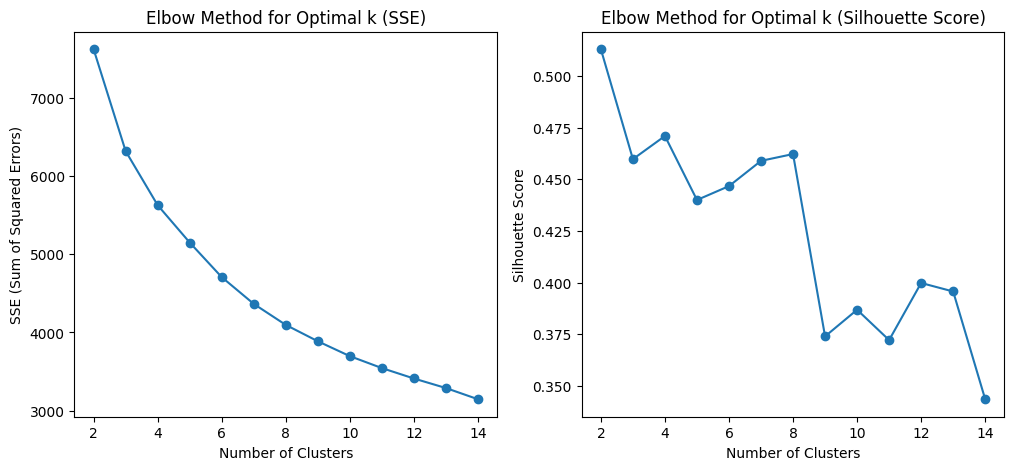

In [61]:
# Подробно:
# 1) Перебираем число кластеров k от 2 до 14.
# 2) Считаем SSE и silhouette-score для каждого k.
# 3) Строим два «локтя»: по SSE и по silhouette-score.

# импортируем библиотеки
import matplotlib.pyplot as plt
# импортируем объекты из модуля
from sklearn.cluster import KMeans
# импортируем объекты из модуля
from sklearn.metrics import silhouette_samples, silhouette_score


# задаем или обновляем xaxs
xaxs = list(range(2, 15))
# задаем или обновляем kmeans_kwargs
kmeans_kwargs = {
    # выполняем шаг вычисления
    "init": "k-means++",
    # выполняем шаг вычисления
    "n_init": 10,
    # выполняем шаг вычисления
    "random_state": 42,
    # выполняем шаг вычисления
    "algorithm": "lloyd"
# выполняем шаг вычисления
}

# задаем или обновляем silhouette_scores
silhouette_scores = []
# задаем или обновляем sse
sse = []

# начинаем цикл for
for k in xaxs:
    # задаем или обновляем kmeans
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    # выполняем шаг вычисления
    kmeans.fit(X)
    # выполняем шаг вычисления
    sse.append(kmeans.inertia_)

    # задаем или обновляем silhouette_avg
    silhouette_avg = silhouette_score(X, kmeans.labels_)
    # выполняем шаг вычисления
    silhouette_scores.append(silhouette_avg)

# строим или настраиваем график
plt.figure(figsize=(12, 5))

# SSE
# строим или настраиваем график
plt.subplot(1, 2, 1)
# строим или настраиваем график
plt.plot(xaxs, sse, marker='o')
# строим или настраиваем график
plt.xlabel('Number of Clusters')
# строим или настраиваем график
plt.ylabel('SSE (Sum of Squared Errors)')
# строим или настраиваем график
plt.title('Elbow Method for Optimal k (SSE)')

# Silhouette Score
# строим или настраиваем график
plt.subplot(1, 2, 2)
# строим или настраиваем график
plt.plot(xaxs, silhouette_scores, marker='o')
# строим или настраиваем график
plt.xlabel('Number of Clusters')
# строим или настраиваем график
plt.ylabel('Silhouette Score')
# строим или настраиваем график
plt.title('Elbow Method for Optimal k (Silhouette Score)')

# строим или настраиваем график
plt.show()

4 кластера выглядит хорошо. 8 тоже.

In [62]:
# Подробно:
# 1) Обучаем KMeans с выбранным k.
# 2) Получаем метки кластеров для всех объектов.

# задаем или обновляем kmeans
kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
# выполняем шаг вычисления
kmeans.fit(X)
# задаем или обновляем cluster_labels
cluster_labels = kmeans.labels_

Посмотрим на то, что получается. 6-мерный вектор будет проблематично отобразить на плоскости, поэтому прибегнем к снижению размерности - переходом в меньшее по количеству измерений признаковое пространство. Рассмотрим три подхода, имеющих реализацию "из коробки" - PCA, t-SNE, UMAP.

**PCA (метод главных компонент)** - это линейный алгоритм, который используется для уменьшения размерности данных путем проекции их на пространство меньшей размерности, сохраняя при этом максимальное количество информации в данных. Это достигается путем определения новых осей (главных компонент), которые направлены в сторону максимальной дисперсии данных. Первая главная компонента имеет наибольшую дисперсию, вторая - максимальную дисперсию среди оставшихся компонент и так далее. Для выбора количества главных компонент часто используют критерий, основанный на объясненной дисперсии, то есть на той доле общей дисперсии, которую объясняют выбранные компоненты.

**t-SNE (Стохастическое вложение соседей с t-распределением)** - это нелинейный алгоритм, который работает на основе вероятностных распределений: в многомерном пространстве данные моделируются так, что похожие объекты имеют высокую вероятность быть "соседями", в то время как непохожие объекты - низкую. Эти вероятности затем используются для определения расположения объектов в пространстве уменьшенной размерности таким образом, чтобы структура данных оставалась похожей. Чем-то напоминает kNN.


**UMAP (Uniform Manifold Approximation and Projection)** - это современный алгоритм уменьшения размерности, который можно считать конкурентом t-SNE. Он также основан на концепции многомерного многообразия, но использует другой математический подход, основанный на топологии. UMAP стремится сохранить глобальную структуру данных, в отличие от t-SNE, который фокусируется больше на локальной.

[Немного красивых картинок](https://habr.com/ru/companies/newprolab/articles/350584/)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


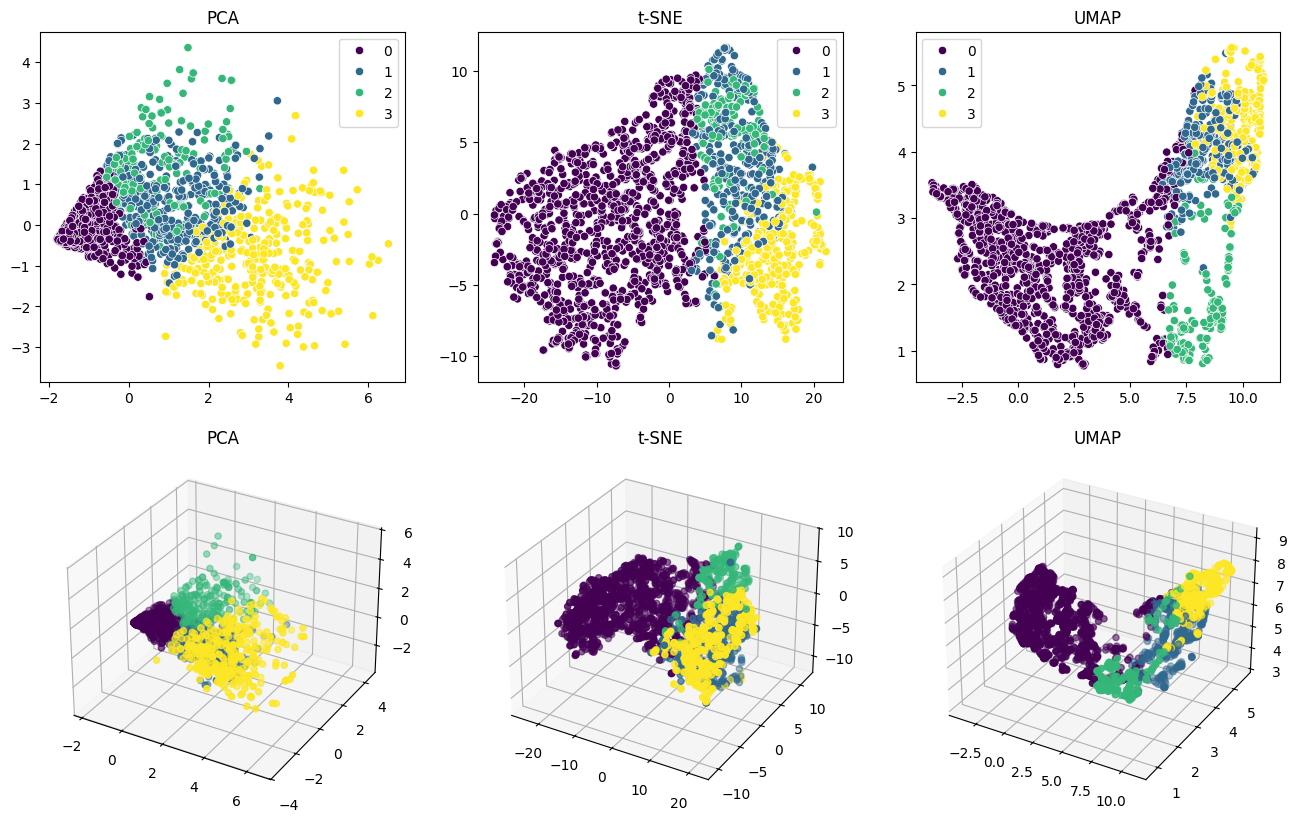

In [63]:
# Подробно:
# 1) Настраиваем PCA, t-SNE и UMAP в 3D.
# 2) Получаем низкоразмерные представления.
# 3) Рисуем 2D и 3D графики, окрашенные по кластерам.

# импортируем объекты из модуля
from sklearn.decomposition import PCA
# импортируем объекты из модуля
from sklearn.manifold import TSNE
# импортируем объекты из модуля
from umap import UMAP
# импортируем объекты из модуля
from mpl_toolkits.mplot3d import Axes3D


# задаем или обновляем pca
pca = PCA(n_components=3)
# задаем или обновляем tsne
tsne = TSNE(n_components=3, random_state=42)
# задаем или обновляем umap
umap = UMAP(n_components=3, random_state=42)

# задаем или обновляем pca_result
pca_result = pca.fit_transform(X)
# задаем или обновляем tsne_result
tsne_result = tsne.fit_transform(X)
# задаем или обновляем umap_result
umap_result = umap.fit_transform(X)

# строим или настраиваем график
plt.figure(figsize=(16, 10))

# 2D Plots
# строим или настраиваем график
plt.subplot(2, 3, 1)
# строим график с seaborn
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cluster_labels, palette='viridis')
# строим или настраиваем график
plt.title('PCA')

# строим или настраиваем график
plt.subplot(2, 3, 2)
# строим график с seaborn
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=cluster_labels, palette='viridis')
# строим или настраиваем график
plt.title('t-SNE')

# строим или настраиваем график
plt.subplot(2, 3, 3)
# строим график с seaborn
sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=cluster_labels, palette='viridis')
# строим или настраиваем график
plt.title('UMAP')

# 3D Plots
# задаем или обновляем ax1
ax1 = plt.subplot(2, 3, 4, projection='3d')
# задаем или обновляем ax1.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c
ax1.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c=cluster_labels, cmap='viridis')
# выполняем шаг вычисления
ax1.set_title('PCA')

# задаем или обновляем ax2
ax2 = plt.subplot(2, 3, 5, projection='3d')
# задаем или обновляем ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c
ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c=cluster_labels, cmap='viridis')
# выполняем шаг вычисления
ax2.set_title('t-SNE')

# задаем или обновляем ax3
ax3 = plt.subplot(2, 3, 6, projection='3d')
# задаем или обновляем ax3.scatter(umap_result[:, 0], umap_result[:, 1], umap_result[:, 2], c
ax3.scatter(umap_result[:, 0], umap_result[:, 1], umap_result[:, 2], c=cluster_labels, cmap='viridis')
# выполняем шаг вычисления
ax3.set_title('UMAP')

# строим или настраиваем график
plt.show()

Попробуйте проинтерпретировать получающиеся результаты.

In [64]:
# Подробно:
# 1) Добавляем метки кластеров в таблицу products.
# 2) Считаем количество объектов в каждом кластере.

# задаем или обновляем products['cluster_labels']
products['cluster_labels'] = cluster_labels
# выполняем шаг вычисления
products['cluster_labels'].value_counts()

,count
cluster_labels,
0,1297
1,392
3,347
2,204


In [65]:
# Подробно:
# 1) Считаем средние значения признаков по кластерам.
# 2) Визуализируем таблицу с градиентом для удобства сравнения.

# задаем или обновляем cluster_means
cluster_means = products.drop(columns='id').groupby('cluster_labels').mean()
# задаем или обновляем cluster_means.style.background_gradient(cmap
cluster_means.style.background_gradient(cmap='Blues', axis=0)  # можно ли сказать, что у нас есть кластер любителей вина?..

,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods
cluster_labels,,,,,,
0,96.339244,6.353123,35.407864,8.926754,6.353123,17.320740
1,717.056122,35.826531,366.737245,53.158163,35.084184,39.551020
2,472.176471,25.730392,169.426471,32.328431,25.029412,143.426471
3,514.276657,90.443804,431.469741,129.815562,96.605187,90.435159


### Задание

В предыдущем пункте работы мы применили готовый код для кластеризации, чтобы увидеть, как она работает. Теперь ваша задача - написать код для реализации алгоритма kMeans самостоятельно (речь, конечно, идет о намного менее, нежели версия "из коробки", оптимизированной версии алгоритма).

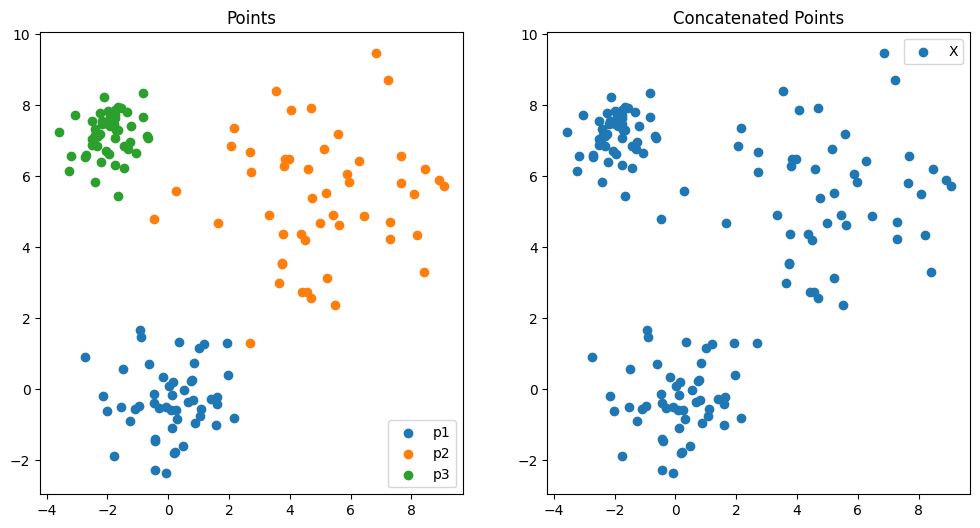

In [66]:
# Подробно:
# 1) Генерируем три набора случайных точек (игрушечные данные).
# 2) Объединяем их и визуализируем исходные кластеры.

# импортируем библиотеки
import numpy as np
# импортируем библиотеки
import matplotlib.pyplot as plt


# игрушечные данные
# задаем или обновляем p1
p1 = np.random.normal(loc=0, scale=1, size=(50,2))
# задаем или обновляем p2
p2 = np.random.normal(loc=5, scale=2, size=(50,2))
# задаем или обновляем p3
p3 = np.random.normal(loc=3, scale=0.6, size=(50,2)) - np.array([5, -4])
# задаем или обновляем X
X = np.concatenate((p1, p2, p3))

# задаем или обновляем fig, axs
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# задаем или обновляем axs[0].scatter(p1[:, 0], p1[:, 1], label
axs[0].scatter(p1[:, 0], p1[:, 1], label='p1')
# задаем или обновляем axs[0].scatter(p2[:, 0], p2[:, 1], label
axs[0].scatter(p2[:, 0], p2[:, 1], label='p2')
# задаем или обновляем axs[0].scatter(p3[:, 0], p3[:, 1], label
axs[0].scatter(p3[:, 0], p3[:, 1], label='p3')
# выполняем шаг вычисления
axs[0].set_title('Points')
# выполняем шаг вычисления
axs[0].legend()

# задаем или обновляем axs[1].scatter(X[:, 0], X[:, 1], label
axs[1].scatter(X[:, 0], X[:, 1], label='X')
# выполняем шаг вычисления
axs[1].set_title('Concatenated Points')
# выполняем шаг вычисления
axs[1].legend()

# строим или настраиваем график
plt.show()

### 1
Напишите функцию, которая рассчитывает расстояния от центров кластеров до каждой точки и возвращает, к какому кластеру принадлежит каждая точка.

In [69]:
# Подробно:
# 1) Функция kmeans_predict находит ближайший центроид для каждой точки.
# 2) Возвращает массив меток кластеров.

# импортируем библиотеки
import scipy


# определяем функцию kmeans_predict
def kmeans_predict(X, clusters):
  # задаем или обновляем X
  X = np.asarray(X, dtype= float)

  # задаем или обновляем dists
  dists = np.linalg.norm(X[:, None, :] - clusters[None, :, :], axis=2)

  # задаем или обновляем labels
  labels = np.argmin(dists, axis=1 )

  # возвращаем результат
  return labels

Посмотрим, что получается.

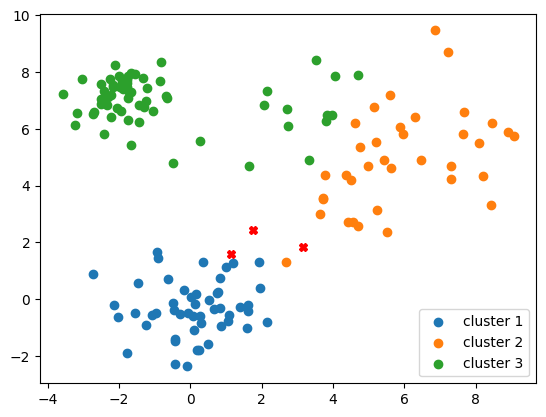

In [70]:
# Подробно:
# 1) Инициализируем случайные центроиды.
# 2) Присваиваем каждой точке ближайший центроид.
# 3) Рисуем точки и центры кластеров.

# случайные координаты для центров кластеров
# задаем или обновляем centroids
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))

# задаем или обновляем labels
labels = kmeans_predict(X, centroids)

# строим или настраиваем график
plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
# строим или настраиваем график
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
# строим или настраиваем график
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
# строим или настраиваем график
plt.plot(centroids[:, 0], centroids[:, 1], 'rX')
# строим или настраиваем график
plt.legend()
# строим или настраиваем график
plt.show()

### 2
Напишите код для обновления центров кластеров. Запоминайте центры кластеров для дальнейшей визуализации.

In [71]:
# Подробно:
# 1) Запускаем несколько итераций k-means.
# 2) На каждой итерации пересчитываем центры как среднее по кластеру.
# 3) Сохраняем историю центроидов для визуализации процесса.

# задаем или обновляем centroids
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))
# задаем или обновляем k
k = len(centroids)
# задаем или обновляем centroids_history
centroids_history = [centroids] # история центров кластеров

# задаем или обновляем iters
iters = 7 # количество шагов итерации обновления центров кластеров

# начинаем цикл for
for i in range(iters):
  # задаем или обновляем lebels
  lebels = kmeans_predict(X, centroids)
  # задаем или обновляем new_centroids
  new_centroids = centroids.copy()

  # начинаем цикл for
  for j in range(k):
    # выполняем шаг вычисления
    points_j = X[labels == j]
    # проверяем условие
    if len(points_j) > 0:
      # задаем или обновляем new_centroids[j]
      new_centroids[j] = points_j.mean(axis=0)

  # задаем или обновляем centroids
  centroids = new_centroids
  # выполняем шаг вычисления
  centroids_history.append(centroids.copy())

Посмотрим на результат.

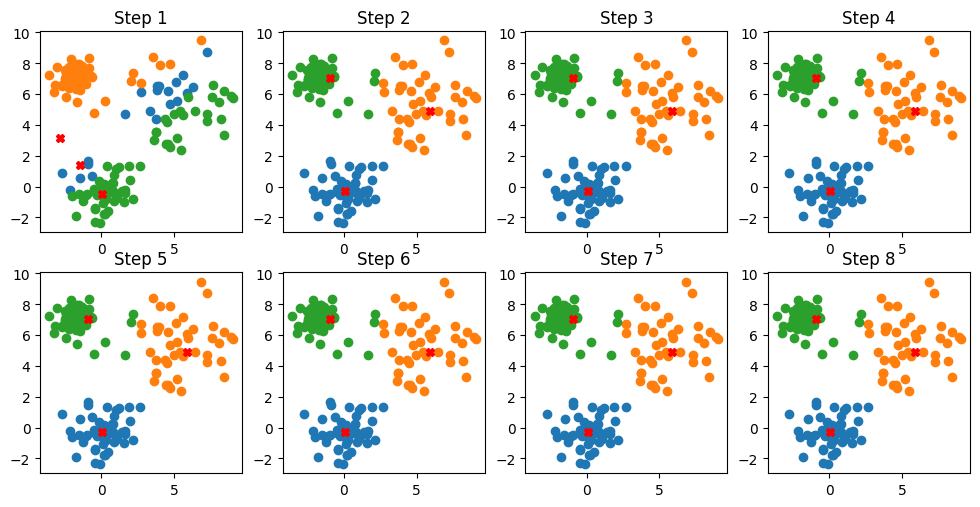

In [72]:
# Подробно:
# 1) Для каждого шага из истории пересчитываем метки.
# 2) Строим подграфики, показывая эволюцию кластеров.

# строим или настраиваем график
plt.figure(figsize=(12, 12))

# начинаем цикл for
for i in range(iters + 1):
    # задаем или обновляем labels
    labels = kmeans_predict(X, centroids_history[i])
    # строим или настраиваем график
    plt.subplot((iters + 1) // 2, (iters + 1) // 2, i + 1)
    # строим или настраиваем график
    plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
    # строим или настраиваем график
    plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
    # строим или настраиваем график
    plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
    # строим или настраиваем график
    plt.plot(centroids_history[i][:, 0], centroids_history[i][:, 1], 'rX')
    # plt.legend()
    # строим или настраиваем график
    plt.title('Step {:}'.format(i + 1))

### 3

Напишите функцию обучения kMeans. Параметры:

* k - кол-во кластеров,
* max_iter - через сколько итераций нужно остановиться,
* tol - если сумма расстояний между прошлыми центрами кластеров и новыми центрами меньше tol (для всех кластеров!), то остановиться,
* low и high - это минимально и максимально значение, которое могут принимать точки центров кластеров при генерации.



Начните с генерации центров кластеров с помощью np.random.uniform. Затем на каждой итерации нужно сделать следующее:
* определить, к какому кластеру относится каждая точка,
* по точкам в кластере пересчитать центр кластера, если точек в кластере нет - сгенерировать новый случайный центр,
* посчитать loss как сумму расстояний (euclidean) между кластерами, полученными на прошлой итерации, и новыми кластерами.

In [79]:
# Подробно:
# 1) Полная реализация k-means: инициализация центроидов.
# 2) Повторяем: присвоение меток → пересчет центров.
# 3) Считаем loss как сдвиг центроидов и проверяем сходимость.
# 4) Возвращаем центроиды, метки и историю потерь.

# импортируем библиотеки
import numpy as np
# импортируем объекты из модуля
from scipy.spatial.distance import cdist


# определяем функцию kmeans_fit_predict
def kmeans_fit_predict(x, k=8, max_iter=100, tol=0.001, low=0.0, high=1.0, print_progress=False):


  # задаем или обновляем x
  x = np.asarray(x, dtype= float)

  # задаем или обновляем n_samples, n_features
  n_samples, n_features = x.shape

  # задаем или обновляем clusters
  clusters = np.random.uniform(low=low, high=high, size= (k, n_features))

  # задаем или обновляем loss_history
  loss_history = []

  # начинаем цикл for
  for it in range(max_iter):
    # задаем или обновляем prev_clusters
    prev_clusters = clusters.copy()

    # задаем или обновляем dists
    dists = cdist(x, clusters, metric = 'euclidean')

    # задаем или обновляем labels
    labels = np.argmin(dists, axis=1)

    # начинаем цикл for
    for j in range(k):
      # выполняем шаг вычисления
      pts = x[labels == j]
      # проверяем условие
      if pts.shape[0] > 0:
        # задаем или обновляем clusters[j]
        clusters[j] = pts.mean(axis= 0)
      # ветка иначе
      else:
        # задаем или обновляем clusters[j]
        clusters[j] = np.random.uniform(low=low, high=high, size= n_features)

    # задаем или обновляем loss
    loss = np.linalg.norm(clusters - prev_clusters, axis=1).sum()
    # выполняем шаг вычисления
    loss_history.append(loss)

    # проверяем условие
    if print_progress:
      # выводим результат
      print(f"iter={it+1}, loss= {loss:.6f}")

    # проверяем условие
    if loss < tol:
      # выполняем шаг вычисления
      break

  # задаем или обновляем dists
  dists = cdist(x, clusters, metric= "euclidean")
  # задаем или обновляем labels
  labels = np.argmin(dists, axis=1 )

  # возвращаем результат
  return clusters, labels, loss_history

Проверим работу функции.

In [80]:
# Подробно:
# 1) Запускаем kmeans_fit_predict на данных X с k=3.
# 2) Получаем центроиды, метки и историю ошибки.

# задаем или обновляем clusters, labels, loss_history
clusters, labels, loss_history = kmeans_fit_predict(X, k=3, low=0.0, high=np.max(X), print_progress=True)

iter=1, loss= 11.587027
iter=2, loss= 2.648840
iter=3, loss= 0.284460
iter=4, loss= 0.301025
iter=5, loss= 0.155932
iter=6, loss= 0.000000


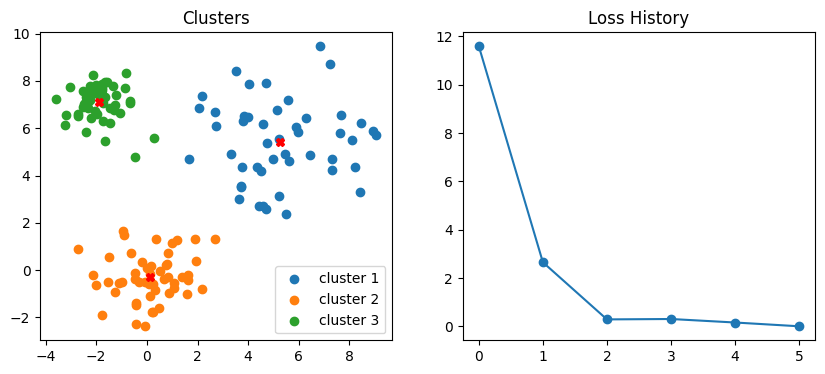

In [81]:
# Подробно:
# 1) Рисуем итоговые кластеры и центроиды.
# 2) Строим график изменения loss по итерациям.

# строим или настраиваем график
plt.figure(figsize=(10, 4))

# строим или настраиваем график
plt.subplot(1, 2, 1)
# строим или настраиваем график
plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
# строим или настраиваем график
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
# строим или настраиваем график
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
# строим или настраиваем график
plt.plot(clusters[:, 0], clusters[:, 1], 'rX')
# строим или настраиваем график
plt.title('Clusters')
# строим или настраиваем график
plt.legend()

# строим или настраиваем график
plt.subplot(1, 2, 2)
# строим или настраиваем график
plt.plot(loss_history, marker='o')
# строим или настраиваем график
plt.title('Loss History')

# строим или настраиваем график
plt.show()